In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score,  f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import learning_curve
from collections import Counter

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the latest version of the dataset directly into a pandas DataFrame
file_path = r"C:\Users\mail2\OneDrive\Desktop\MY_DRIVE\MLOps\MLOps-Addy\Data_Sets\Iris.csv"
dataset = pd.read_csv(file_path)
dataset.head(10)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa


In [3]:
dataset.info()
dataset.describe()
dataset.shape
dataset.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

Categorical Features: ['Species']
Numerical Features: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']


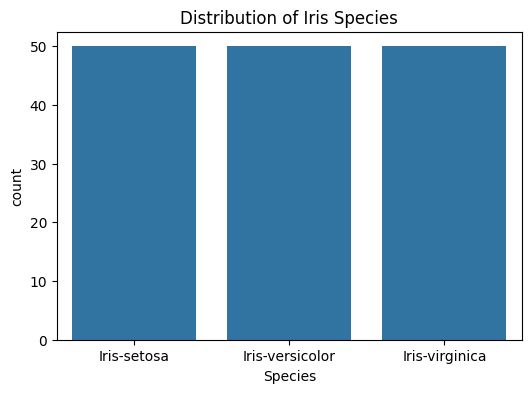

In [31]:
# Categorical features
categorical_features = dataset.select_dtypes(include=['object']).columns.tolist()
print("Categorical Features:", categorical_features)
# Numerical features
numerical_features = dataset.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical Features:", numerical_features)
# Visualize the distribution of species
plt.figure(figsize=(6,4))
sns.countplot(x='Species', data=dataset)
plt.title('Distribution of Iris Species')
plt.show()



In [7]:
# Duplicate check
duplicates = dataset.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
# Missing values check
missing_values = dataset.isnull().sum()
print("Missing values in each column:\n", missing_values)

Number of duplicate rows: 0
Missing values in each column:
 Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [9]:
# Split the dataset into features and target variable
X = dataset.drop(columns=['Species', 'Id'])
y = dataset['Species']
print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Printing before encoding target variable: ", y.unique())
# Encode the target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)  
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)
print("Printing after encoding target variable: ", np.unique(y_encoded))

Features shape: (150, 4)
Target shape: (150,)
Printing before encoding target variable:  ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Training features shape: (120, 4)
Testing features shape: (30, 4)
Training target shape: (120,)
Testing target shape: (30,)
Printing after encoding target variable:  [0 1 2]


Predictions on test set: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]


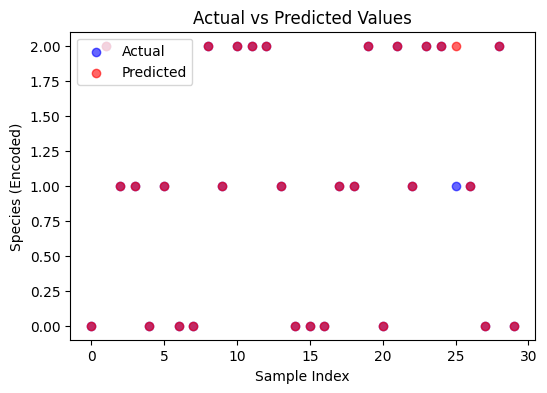

In [33]:
# Initialize the Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier
gb_classifier = GradientBoostingClassifier(random_state=42)
# Train the model
gb_classifier.fit(X_train, y_train)
# Make predictions
y_pred = gb_classifier.predict(X_test)
print("Predictions on test set:", y_pred)
plt.figure(figsize=(6,4))
plt.scatter(range(len(y_test)), y_test, color='blue', label='Actual', alpha=0.6)
plt.scatter(range(len(y_pred)), y_pred, color='red', label='Predicted', alpha=0.6)
plt.title('Actual vs Predicted Values')
plt.xlabel('Sample Index')
plt.ylabel('Species (Encoded)')
plt.legend()
plt.show()

In [13]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Accuracy: 0.9667
Precision: 0.9697
Recall: 0.9667
F1 Score: 0.9666
Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



In [14]:
# Hyperparameter tuning using GridSearchCV
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}
grid_search = GridSearchCV(estimator=gb_classifier, param_grid=param_grid, cv=3, n_jobs=-1, scoring='accuracy')
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)
# Train the model with the best hyperparameters
best_gb_classifier = GradientBoostingClassifier(**best_params, random_state=42)
best_gb_classifier.fit(X_train, y_train)
# Make predictions with the best model
y_pred_best = best_gb_classifier.predict(X_test)
print("Predictions with best model on test set:", y_pred_best)
# Evaluate the best model
best_accuracy = accuracy_score(y_test, y_pred_best)
best_precision = precision_score(y_test, y_pred_best, average='weighted')
best_recall = recall_score(y_test, y_pred_best, average='weighted')
best_f1 = f1_score(y_test, y_pred_best, average='weighted')
print(f"Best Model Accuracy: {best_accuracy:.4f}")
print(f"Best Model Precision: {best_precision:.4f}")
print(f"Best Model Recall: {best_recall:.4f}")
print(f"Best Model F1 Score: {best_f1:.4f}")
print("Best Model Classification Report:\n", classification_report(y_test, y_pred_best, target_names=label_encoder.classes_))

Best Hyperparameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 150}
Predictions with best model on test set: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]
Best Model Accuracy: 0.9667
Best Model Precision: 0.9697
Best Model Recall: 0.9667
Best Model F1 Score: 0.9666
Best Model Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



In [ ]:
# No change after this point

In [15]:
# Pickle the model
import pickle
with open('gradientBoosting_iris_model.pkl', 'wb') as file:
    pickle.dump(best_gb_classifier, file)

In [ ]:
# Load the model from the pickle file - Gradient Boosting model
with open('gradientBoosting_iris_model.pkl', 'rb') as file:
    gb_model = pickle.load(file)
# Make predictions with the loaded model
loaded_model_predictions_rf = gb_model.predict([[5.2,2.1,2.1,1]])
# Print encoded y unique values with descriptions
print("Encoded Y unique values:", y.unique())
print("Predictions from loaded Gradient Boosting model on test set:", loaded_model_predictions_rf)
# Print accuracy of loaded model
loaded_model_accuracy = accuracy_score(y_test, gb_model.predict(X_test))
print(f"Loaded Model Accuracy: {loaded_model_accuracy:.4f}")

# decode the label

Encoded Y unique values: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Predictions from loaded Gradient Boosting model on test set: [0]
Loaded Model Accuracy: 0.9667


In [25]:
# Load the model from the pickle file - Random Forest model
with open('randomForest_iris_model.pkl', 'rb') as file:
    rf_model = pickle.load(file)
# Make predictions with the loaded model
loaded_model_predictions_rf = rf_model.predict([[2.1,2.1,1.2,1.4]])
print("Predictions from loaded Random Forest model on test set:", loaded_model_predictions_rf)

Predictions from loaded Random Forest model on test set: ['Iris-setosa']


In [26]:
#Load the Previous model from the pickle file - Logistic Regression model
with open('logistic_regression_iris_model.pkl', 'rb') as file:
    lor_model = pickle.load(file)
# Make predictions with the loaded model
loaded_model_predictions_lor = lor_model.predict([[991,6.4,2.6,3.5,1.5]])
print("Predictions from loaded Logistic Regression model on test set:", loaded_model_predictions_lor)


Predictions from loaded Logistic Regression model on test set: ['Iris-virginica']
